# Projeto: Telecom X - Análise de Evasão de Clientes (Churn)


## 1. Extração dos Dados (Extract)
Nesta primeira etapa, vamos conectar à API da Telecom X disponível no GitHub, extrair os dados em formato JSON (que possuem colunas aninhadas) e transformá-los em um DataFrame do Pandas.

In [ ]:
import pandas as pd
import requests

# URL raw do arquivo JSON
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json"

# Extração e achatamento (flattening) das colunas aninhadas
df_bruto = pd.read_json(url)
df_customer = pd.json_normalize(df_bruto['customer'])
df_phone = pd.json_normalize(df_bruto['phone'])
df_internet = pd.json_normalize(df_bruto['internet'])
df_account = pd.json_normalize(df_bruto['account'])

# Concatenando tudo em um único DataFrame
df = pd.concat([df_bruto.drop(columns=['customer', 'phone', 'internet', 'account']),
                df_customer, df_phone, df_internet, df_account], axis=1)

display(df.head(3))

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


## 2. Transformação e Limpeza dos Dados (Transform)
Agora vamos tratar as inconsistências. Os passos incluem:
* Corrigir a coluna de Faturamento Total (que veio com espaços em branco).
* Remover valores nulos da variável alvo (`Churn`).
* Traduzir os nomes das colunas para facilitar a análise.
* Transformar a variável de evasão em binária (1 = Sim, 0 = Não).

In [ ]:
# ==========================================
# 2. TRANSFORMAÇÃO E LIMPEZA DOS DADOS
# ==========================================

# 1. Tratamento de nulos e tipos de dados
df['Charges.Total'] = df['Charges.Total'].replace(' ', pd.NA)
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')
df = df[df['Churn'] != '']
df = df.dropna(subset=['Churn'])

# 2. Tradução dos nomes das colunas
colunas_traduzidas = {
    'gender': 'genero', 'SeniorCitizen': 'idoso', 'Partner': 'parceiro',
    'Dependents': 'dependentes', 'tenure': 'meses_contrato',
    'PhoneService': 'servico_telefone', 'Contract': 'tipo_contrato',
    'PaymentMethod': 'metodo_pagamento', 'Charges.Monthly': 'gasto_mensal',
    'Charges.Total': 'gasto_total', 'Churn': 'evasao'
}
df.rename(columns=colunas_traduzidas, inplace=True)

# 3. TRADUÇÃO DO CONTEÚDO (Mudar de Inglês para Português)
mapa_contrato = {'Month-to-month': 'Mensal', 'One year': 'Anual', 'Two year': 'Bianual'}
mapa_pagamento = {
    'Electronic check': 'Cheque Eletrônico', 'Mailed check': 'Cheque via Correio',
    'Bank transfer (automatic)': 'Transferência Bancária', 'Credit card (automatic)': 'Cartão de Crédito'
}
mapa_genero = {'Female': 'Feminino', 'Male': 'Masculino'}

df['tipo_contrato'] = df['tipo_contrato'].map(mapa_contrato).fillna(df['tipo_contrato'])
df['metodo_pagamento'] = df['metodo_pagamento'].map(mapa_pagamento).fillna(df['metodo_pagamento'])
df['genero'] = df['genero'].map(mapa_genero).fillna(df['genero'])

# 4. Conversão Binária e padronização de texto
df['evasao'] = df['evasao'].map({'Yes': 1, 'No': 0, 'yes': 1, 'no': 0})

colunas_categoricas = df.select_dtypes(include=['object']).columns
for col in colunas_categoricas:
    df[col] = df[col].astype(str).str.strip()

print(f"Dados limpos e traduzidos com sucesso! Total de linhas: {df.shape[0]}")
display(df[['genero', 'tipo_contrato', 'metodo_pagamento', 'evasao']].head())

Dados limpos e traduzidos com sucesso! Total de linhas: 7043


,genero,tipo_contrato,metodo_pagamento,evasao
0,Feminino,Anual,Cheque via Correio,0
1,Masculino,Mensal,Cheque via Correio,0
2,Masculino,Mensal,Cheque Eletrônico,1
3,Masculino,Mensal,Cheque Eletrônico,1
4,Feminino,Mensal,Cheque via Correio,1


## 3. Criação de Métricas e Carga (Load)
Para enriquecer a análise, vamos criar a coluna `conta_diaria` e exportar nosso DataFrame limpo para um arquivo CSV.

In [ ]:
# ==========================================
#  Criando métrica de conta diária
# ==========================================
df['conta_diaria'] = round(df['gasto_mensal'] / 30, 2)

# ==========================================
# EXPORTAÇÃO DOS DADOS (LOAD)
# ==========================================

# Nome do arquivo final
nome_arquivo = 'TelecomX_Dados_Limpos.csv'

# Salvando de forma compatível com a visualização do GitHub
# index=False remove a coluna de números à esquerda
# encoding='utf-8' garante que acentos (como "Feminino") apareçam corretos
df.to_csv(nome_arquivo, index=False, encoding='utf-8', sep=',')

print(f"Arquivo '{nome_arquivo}' pronto para o GitHub!")

Arquivo 'TelecomX_Dados_Limpos.csv' pronto para o GitHub!


## 4. Análise Exploratória (EDA): Visão Geral
Vamos iniciar verificando as estatísticas descritivas (média, mediana, desvio padrão) e a distribuição da nossa variável principal: a evasão de clientes.

,evasao,idoso,meses_contrato,gasto_mensal,gasto_total
count,7043.00,7043.00,7043.00,7043.00,7032.00
mean,0.27,0.16,32.37,64.76,2283.30
std,0.44,0.37,24.56,30.09,2266.77
min,0.00,0.00,0.00,18.25,18.80
25%,0.00,0.00,9.00,35.50,401.45
50%,0.00,0.00,29.00,70.35,1397.48
75%,1.00,0.00,55.00,89.85,3794.74
max,1.00,1.00,72.00,118.75,8684.80


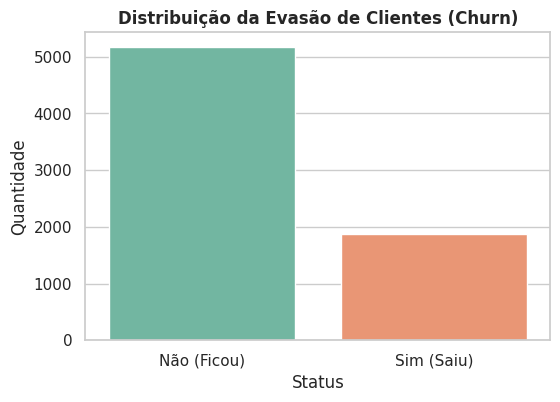

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# Estatísticas descritivas
display(df.describe().round(2))

# Gráfico da variável alvo
df['status_evasao'] = df['evasao'].map({1: 'Sim (Saiu)', 0: 'Não (Ficou)'})

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='status_evasao', hue='status_evasao', palette='Set2', legend=False)
plt.title('Distribuição da Evasão de Clientes (Churn)', fontweight='bold')
plt.xlabel('Status')
plt.ylabel('Quantidade')
plt.show()

# 5. EDA: Comportamento por Perfil e Finanças
Nesta etapa, analisamos como variáveis categóricas (contrato, gênero e pagamento) e numéricas (tempo de contrato e gastos) impactam o cancelamento. Também geramos uma Matriz de Correlação.

## 5. Análise de Perfil: Tipo de Contrato
Vamos investigar se o tipo de fidelidade do cliente impacta na taxa de cancelamento.

## 5.2. O Gráfico da Variável Alvo (O "Ponto de Partida")
Este mostra o equilíbrio (ou desequilíbrio) dos seus dados.

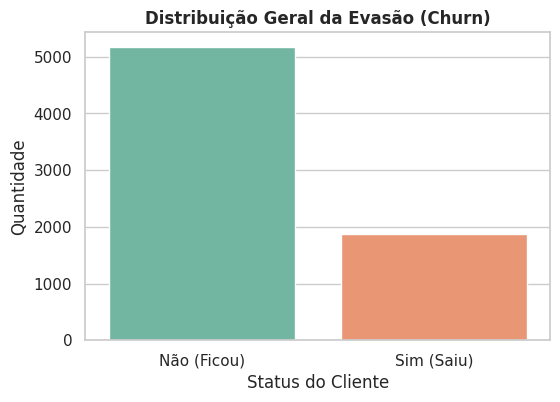

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='status_evasao', hue='status_evasao', palette='Set2', legend=False)
plt.title('Distribuição Geral da Evasão (Churn)', fontsize=12, fontweight='bold')
plt.xlabel('Status do Cliente')
plt.ylabel('Quantidade')
plt.show()

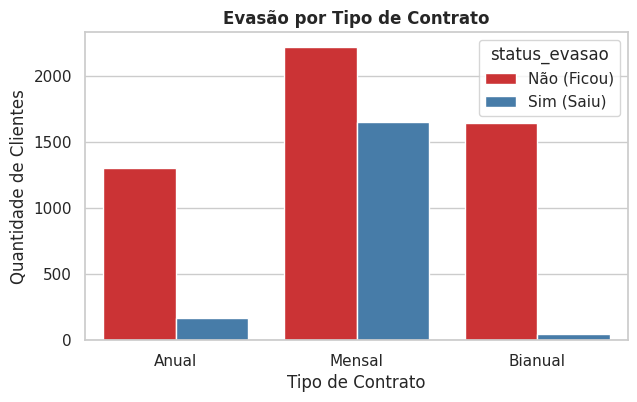

In [ ]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='tipo_contrato', hue='status_evasao', palette='Set1')
plt.title('Evasão por Tipo de Contrato', fontweight='bold')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Quantidade de Clientes')
plt.show()

## 5.3. Análise de Perfil: Método de Pagamento
Será que a forma como o cliente paga a fatura influencia na sua decisão de sair da Telecom X?

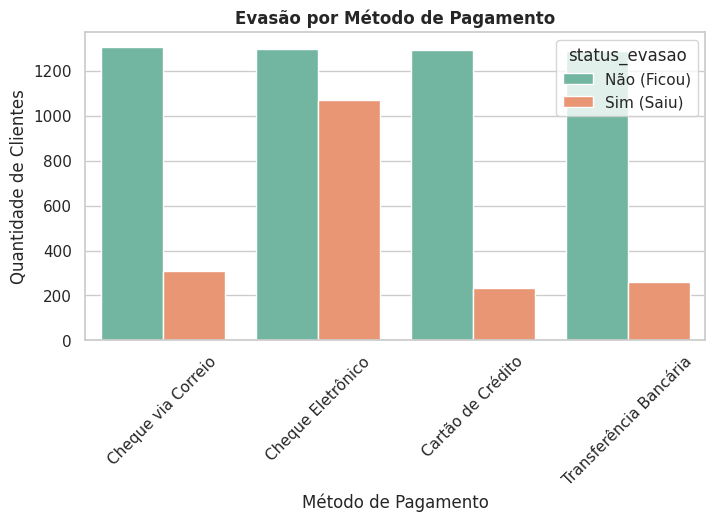

In [ ]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='metodo_pagamento', hue='status_evasao', palette='Set2')
plt.title('Evasão por Método de Pagamento', fontweight='bold')
plt.xlabel('Método de Pagamento')
plt.ylabel('Quantidade de Clientes')
plt.xticks(rotation=45) # Rotaciona o texto para não encavalar
plt.show()

## 5.4. Análise Demográfica: Gênero
Aqui verificamos se o gênero do titular da conta é um fator determinante para o churn.

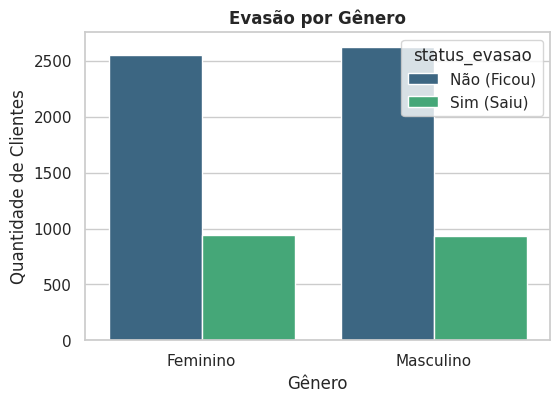

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='genero', hue='status_evasao', palette='viridis')
plt.title('Evasão por Gênero', fontweight='bold')
plt.xlabel('Gênero')
plt.ylabel('Quantidade de Clientes')
plt.show()

## 5.5. Análise Contínua: Tempo de Contrato (Tenure)
Qual é o período mais crítico para a empresa? Vamos analisar o volume de cancelamentos de acordo com os meses de vida do cliente.

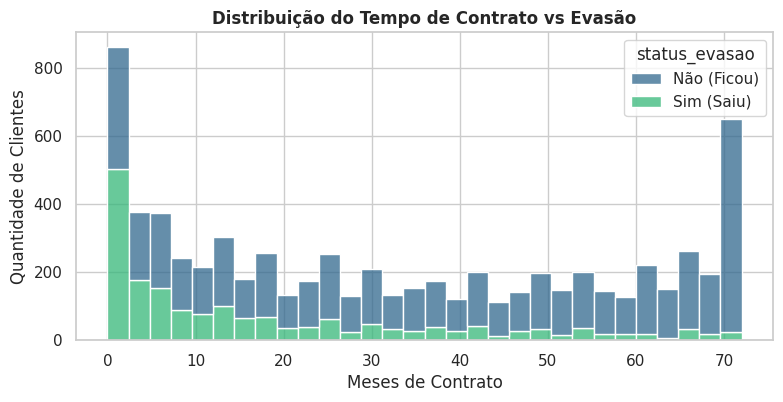

In [ ]:
plt.figure(figsize=(9, 4))
sns.histplot(data=df, x='meses_contrato', hue='status_evasao', multiple='stack', bins=30, palette='viridis')
plt.title('Distribuição do Tempo de Contrato vs Evasão', fontweight='bold')
plt.xlabel('Meses de Contrato')
plt.ylabel('Quantidade de Clientes')
plt.show()

## 5.6. Análise Financeira: Gasto Mensal
Vamos utilizar um Boxplot para entender se faturas mais caras geram maior atrito e, consequentemente, mais cancelamentos.

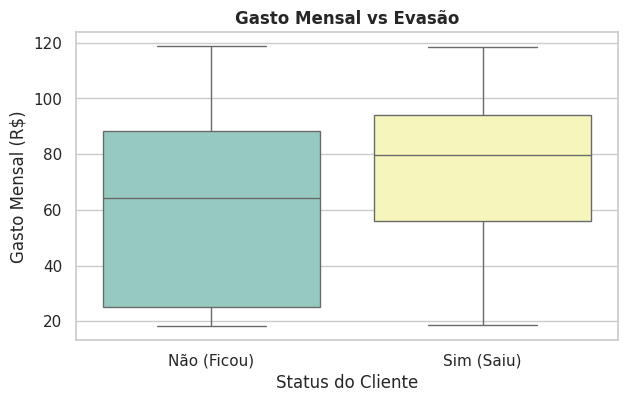

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='status_evasao', y='gasto_mensal', hue='status_evasao', palette='Set3', legend=False)
plt.title('Gasto Mensal vs Evasão', fontweight='bold')
plt.xlabel('Status do Cliente')
plt.ylabel('Gasto Mensal (R$)')
plt.show()

## 5.7. Validação Matemática: Matriz de Correlação
Para finalizar nossa Análise Exploratória, vamos cruzar todas as variáveis numéricas para confirmar matematicamente as tendências que vimos nos gráficos anteriores.

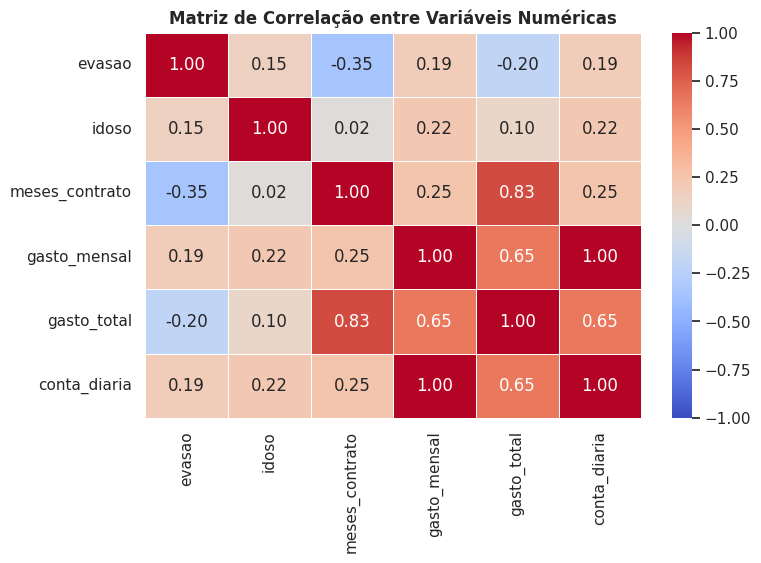

In [ ]:
# Selecionando apenas as colunas numéricas
colunas_numericas = df.select_dtypes(include=['number'])

plt.figure(figsize=(8, 5))
sns.heatmap(colunas_numericas.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlação entre Variáveis Numéricas', fontweight='bold')
plt.show()

# Limpando a coluna temporária que usamos apenas para os gráficos
df.drop(columns=['status_evasao'], inplace=True)

# 📊 Relatório Final: Análise de Evasão de Clientes (Churn) - Telecom X

## 1. Introdução

O objetivo deste projeto é analisar os dados de clientes da Telecom X para entender os principais fatores que levam à evasão (*Churn*). Compreender esse comportamento é fundamental para que a equipe de Data Science possa avançar para a criação de modelos preditivos, e para que a área de Negócios possa desenvolver campanhas de retenção mais eficientes.

## 2. Limpeza e Tratamento de Dados (ETL)

Os dados foram extraídos via API em formato JSON aninhado. O processo de preparação envolveu as seguintes etapas:

* **Achatamento (Flattening):** Extração das colunas aninhadas (`customer`, `phone`, `internet`, `account`) utilizando a função `json_normalize` do Pandas.
* **Tratamento de Inconsistências:** A coluna de Gasto Total (`Charges.Total`), que possuía espaços em branco em vez de valores nulos, foi tratada e convertida adequadamente para o formato numérico.
* **Limpeza:** Remoção de registros que não possuíam a informação da variável alvo (`Churn`) e padronização de strings para evitar duplicidades por erros de digitação.

## 3. Transformações Avançadas e Novas Métricas

Para aprofundar a análise e facilitar a comunicação com os *stakeholders* (áreas de negócio), realizamos a padronização e tradução das variáveis para o português.

* **Conversão Binária:** A variável alvo (`evasao`) foi convertida para o formato numérico (1 para "Sim" e 0 para "Não"), permitindo a aplicação de cálculos estatísticos.
* **Criação de Variável:** Criamos a métrica **`conta_diaria`** (gasto mensal dividido por 30). Essa nova variável proporciona uma visão mais granular do impacto financeiro no dia a dia do cliente, ajudando a entender sua sensibilidade ao preço.

## 4. Análise Exploratória de Dados (EDA) e Insights Visuais

Com base nos gráficos gerados durante a exploração, observamos os seguintes padrões comportamentais:

* **Tipo de Contrato:** Clientes com contrato mensal ("Month-to-month") apresentam a maior taxa de evasão do dataset. Contratos de 1 ou 2 anos têm uma retenção altíssima.
* **Tempo de Contrato (Tenure):** A evasão é massiva nos primeiros meses. Clientes que ultrapassam a barreira dos primeiros meses tendem a se fidelizar.
* **Método de Pagamento:** Clientes que pagam por "Electronic check" (Boleto/Cheque eletrônico) cancelam muito mais do que os que utilizam débito automático ou cartão de crédito.
* **Gênero:** A taxa de evasão é muito similar entre homens e mulheres, indicando que o gênero não é um fator determinante para o cancelamento na Telecom X.

## 5. Análise de Correlação e Insights Matemáticos

Aplicamos uma Matriz de Correlação (Heatmap) para medir matematicamente como as variáveis numéricas se relacionam com a evasão. Os principais achados confirmam nossas hipóteses visuais:

* **Tempo de Contrato vs. Evasão (Correlação Negativa):** Existe uma correlação inversamente proporcional entre o tempo de contrato e a evasão. Quanto maior o tempo de permanência, menor a probabilidade de cancelamento. Isso comprova que focar na retenção inicial é a estratégia mais eficaz.
* **Gasto Mensal/Diário vs. Evasão (Correlação Positiva):** Clientes com uma `conta_diaria` e `gasto_mensal` mais altos apresentam uma tendência maior a cancelar o serviço. Contas mais caras geram mais atrito e, consequentemente, mais evasão.

## 6. Conclusões e Recomendações

O perfil com maior risco de evasão é o **cliente recém-chegado, com contrato mensal e que paga via boleto/cheque eletrônico**. Para reduzir a evasão de forma estratégica, recomenda-se:

1. **Incentivar contratos anuais:** Oferecer descontos agressivos nos primeiros meses (ou isenção de taxa de instalação) para quem fechar contratos de 1 ou 2 anos.
2. **Mudar o método de pagamento:** Oferecer benefícios (como *cashback*, bônus de internet ou desconto na fatura) para clientes que cadastrarem o cartão de crédito ou débito automático.
3. **Atenção aos novos clientes:** Criar um programa de "boas-vindas" e suporte proativo nos primeiros 3 meses, que é o período mais crítico onde a maioria dos cancelamentos ocorre.

Arquivo 'TelecomX_Dados_Limpos.csv' pronto para o GitHub!
